<a href="https://colab.research.google.com/github/essence-git/esssencegit-workflow/blob/main/stage2_model_build_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 2 — BiGRU Autoencoder: Build and Train

### Architecture decisions
- **Bidirectional GRU encoder** — each flow in the sequence is encoded using both past and future context within the window. This gives richer representations of normal traffic patterns.
- **Unidirectional GRU decoder** — reconstruction is causal (left to right), which is the natural direction for sequence generation and avoids information leakage during reconstruction.
- **Bottleneck** — compresses the bidirectional hidden state (64×2=128) down to 32, forcing the model to learn a compact representation of normal behaviour. Anomalous flows cannot be compressed cleanly, producing high reconstruction error.
- **hidden_size=64** — appropriate for 19 input features and window=10. Larger hidden sizes over-parameterise this problem and reduce the reconstruction error gap between normal and anomalous traffic.
- **LoRA target layers** — `bottleneck` (Linear 128→32) and `decoder_expand` (Linear 32→64). These are frozen after training. Only LoRA matrices are trained during Stage 6 adaptation. GRU weights are never modified after training.

## 2.1 — Model architecture

In [3]:
# ============================================================
# STAGE 2 — Setup: imports, Drive mount, load Stage 1 assets
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import copy, gc, random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import pickle
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, classification_report, accuracy_score
)
from sklearn.tree import DecisionTreeClassifier, export_text
from torch.utils.data import DataLoader, TensorDataset

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

# ── Load Stage 1 assets from Google Drive ────────────────────
SAVE_DIR = '/content/drive/MyDrive/gru_iot_project/'

X_train      = np.load(SAVE_DIR + 'X_train.npy')
X_val        = np.load(SAVE_DIR + 'X_val.npy')
X_period_b   = np.load(SAVE_DIR + 'X_period_b.npy')
X_test       = np.load(SAVE_DIR + 'X_test.npy')
y_test       = np.load(SAVE_DIR + 'y_test.npy')
y_test_class = np.load(SAVE_DIR + 'y_test_class.npy', allow_pickle=True)

with open(SAVE_DIR + 'stage1_assets.pkl', 'rb') as f:
    assets = pickle.load(f)

baseline_means_raw = assets['baseline_means_raw']
scaler             = assets['scaler']
FEATURES           = assets['FEATURES']
WINDOW             = assets['WINDOW']
test_source        = assets['test_source']

print(f'\nStage 1 assets loaded.')
print(f'  X_train    : {X_train.shape}')
print(f'  X_val      : {X_val.shape}')
print(f'  X_period_b : {X_period_b.shape}')
print(f'  X_test     : {X_test.shape}')
print(f'  y_test     : {y_test.shape}')
print(f'  Features   : {len(FEATURES)}')
print(f'  Window     : {WINDOW}')

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

Mounted at /content/drive
Device : cuda
GPU    : Tesla T4

Stage 1 assets loaded.
  X_train    : (278822, 10, 19)
  X_val      : (59740, 10, 19)
  X_period_b : (59741, 10, 19)
  X_test     : (113360, 10, 19)
  y_test     : (113360,)
  Features   : 19
  Window     : 10


In [4]:
class GRUAutoencoder(nn.Module):
    """
    BiGRU Autoencoder for unsupervised IoT anomaly detection.

    Encoder  : Bidirectional GRU  (input_size -> hidden_size, bidirectional)
                 Output dim at final timestep: hidden_size * 2 (128)
    Bottleneck: Linear 128 -> 32  (compression; LoRA target in Stage 6)
    Expand   : Linear 32 -> 64   (LoRA target in Stage 6)
    Decoder  : Unidirectional GRU (hidden_size -> input_size)
                 Reconstructs the original sequence flow by flow

    Forward returns (reconstruction, bottleneck_repr).
    bottleneck_repr is used by the surrogate decision tree in Stage 4.
    """
    def __init__(self, input_size=len(FEATURES), hidden_size=64,
                 num_layers=2, dropout=0.2):
        super().__init__()

        # ── Encoder: Bidirectional GRU ────────────────────────────────────
        # Reads each 10-flow window in both directions.
        # Final hidden state dim = hidden_size * 2 = 128
        self.encoder = nn.GRU(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.enc_dropout = nn.Dropout(dropout)

        # ── Bottleneck: Linear 128 -> 32 ──────────────────────────────────
        # Forces compact normal-traffic representation.
        # PRIMARY LoRA target in Stage 6.
        self.bottleneck = nn.Linear(hidden_size * 2, 32)

        # ── Expand: Linear 32 -> 64 ───────────────────────────────────────
        # Projects bottleneck back up to decoder hidden size.
        # SECONDARY LoRA target in Stage 6.
        self.decoder_expand = nn.Linear(32, hidden_size)
        self.dec_dropout    = nn.Dropout(dropout)

        # ── Decoder: Unidirectional GRU ───────────────────────────────────
        # Reconstructs the sequence causally (left to right).
        # hidden_size input (not hidden_size*2) — unidirectional.
        self.decoder = nn.GRU(
            hidden_size, input_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

    def forward(self, x):
        seq_len = x.size(1)

        # Encode — take last timestep from bidirectional output
        enc_out, _   = self.encoder(x)              # (batch, seq, hidden*2)
        enc_out      = self.enc_dropout(enc_out[:, -1, :])  # (batch, hidden*2)

        # Compress to bottleneck
        bottleneck   = torch.relu(self.bottleneck(enc_out))  # (batch, 32)

        # Expand and repeat across sequence length for decoder input
        dec_input    = self.dec_dropout(self.decoder_expand(bottleneck))  # (batch, 64)
        dec_input    = dec_input.unsqueeze(1).repeat(1, seq_len, 1)       # (batch, seq, 64)

        # Decode — reconstruct original sequence
        output, _    = self.decoder(dec_input)      # (batch, seq, input_size)

        return output, bottleneck


# ── Instantiate and inspect ───────────────────────────────────────────────────
model = GRUAutoencoder(
    input_size=len(FEATURES),
    hidden_size=64,
    num_layers=2,
    dropout=0.2
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('BiGRU Autoencoder')
print('=' * 50)
print(f'  Input size       : {len(FEATURES)} features')
print(f'  Hidden size      : 64  (bidirectional encoder -> 128)')
print(f'  Bottleneck       : 128 -> 32')
print(f'  Decoder expand   : 32  -> 64')
print(f'  Decoder hidden   : 64  (unidirectional)')
print(f'  Total parameters : {total_params:,}')
print(f'  Trainable        : {trainable_params:,}')
print('=' * 50)
print()

# Layer-by-layer breakdown
print('Layer breakdown:')
for name, param in model.named_parameters():
    print(f'  {name:<35} {str(tuple(param.shape)):<20} {param.numel():>8,} params')

# Smoke test — one forward pass with dummy data
dummy  = torch.zeros(4, WINDOW, len(FEATURES)).to(DEVICE)
out, bn = model(dummy)
print(f'\nSmoke test passed:')
print(f'  Input shape       : {dummy.shape}')
print(f'  Reconstruction    : {out.shape}   (should match input)')
print(f'  Bottleneck repr   : {bn.shape}    (used by surrogate in Stage 4)')

BiGRU Autoencoder
  Input size       : 19 features
  Hidden size      : 64  (bidirectional encoder -> 128)
  Bottleneck       : 128 -> 32
  Decoder expand   : 32  -> 64
  Decoder hidden   : 64  (unidirectional)
  Total parameters : 120,501
  Trainable        : 120,501

Layer breakdown:
  encoder.weight_ih_l0                (192, 19)               3,648 params
  encoder.weight_hh_l0                (192, 64)              12,288 params
  encoder.bias_ih_l0                  (192,)                    192 params
  encoder.bias_hh_l0                  (192,)                    192 params
  encoder.weight_ih_l0_reverse        (192, 19)               3,648 params
  encoder.weight_hh_l0_reverse        (192, 64)              12,288 params
  encoder.bias_ih_l0_reverse          (192,)                    192 params
  encoder.bias_hh_l0_reverse          (192,)                    192 params
  encoder.weight_ih_l1                (192, 128)             24,576 params
  encoder.weight_hh_l1                

## 2.2 — Data loaders

In [5]:
BATCH_SIZE = 512
EPOCHS     = 100
LR         = 0.001
PATIENCE   = 15       # early stopping patience on val loss

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train)),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True,
    worker_init_fn=seed_worker, generator=g
)
val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_val)),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f'Train loader : {len(train_loader):,} batches  ({len(train_loader.dataset):,} sequences)')
print(f'Val loader   : {len(val_loader):,} batches  ({len(val_loader.dataset):,} sequences)')

Train loader : 545 batches  (278,822 sequences)
Val loader   : 117 batches  (59,740 sequences)


## 2.3 — Training loop

- **Loss:** MSE between input sequence and reconstruction — the standard unsupervised autoencoder objective. No attack labels used at any point.
- **Optimiser:** Adam with weight decay 1e-4 to regularise the bottleneck.
- **Scheduler:** ReduceLROnPlateau — halves LR when val loss plateaus for 5 epochs.
- **Early stopping:** patience of 15 epochs on val loss. Best weights saved to disk.
- **Gradient clipping:** max norm 1.0 — stabilises GRU training.

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)
criterion = nn.MSELoss()

best_val_loss    = float('inf')
patience_counter = 0
train_losses     = []
val_losses       = []

print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>12} {'LR':>10} {'Status':>20}")
print('-' * 65)

for epoch in range(1, EPOCHS + 1):

    # ── Training ─────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        recon, _ = model(batch)
        loss     = criterion(recon, batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * batch.size(0)
    train_loss /= len(train_loader.dataset)

    # ── Validation ───────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for (batch,) in val_loader:
            batch    = batch.to(DEVICE)
            recon, _ = model(batch)
            val_loss += criterion(recon, batch).item() * batch.size(0)
    val_loss /= len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # ── Checkpoint ───────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'gru_best_model.pt')
        status = '  best saved'
    else:
        patience_counter += 1
        status = f'  patience {patience_counter}/{PATIENCE}'

    current_lr = optimizer.param_groups[0]['lr']
    print(f"{epoch:>6} {train_loss:>12.6f} {val_loss:>12.6f} {current_lr:>10.6f} {status:>20}")

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        print(f'Best val loss: {best_val_loss:.6f}')
        break

print(f'\nTraining complete. Best val MSE: {best_val_loss:.6f}')

 Epoch   Train Loss     Val Loss         LR               Status
-----------------------------------------------------------------
     1     0.045979     0.044444   0.001000           best saved
     2     0.042295     0.044327   0.001000           best saved
     3     0.042094     0.044358   0.001000        patience 1/15
     4     0.042013     0.044291   0.001000           best saved
     5     0.041968     0.044303   0.001000        patience 1/15
     6     0.041930     0.044351   0.001000        patience 2/15
     7     0.041887     0.044321   0.001000        patience 3/15
     8     0.041861     0.044315   0.001000        patience 4/15
     9     0.041846     0.044328   0.001000        patience 5/15
    10     0.041837     0.044314   0.000500        patience 6/15
    11     0.041824     0.044321   0.000500        patience 7/15
    12     0.041822     0.044320   0.000500        patience 8/15
    13     0.041820     0.044266   0.000500           best saved
    14     0.041820     

## 2.4 — Training convergence plot

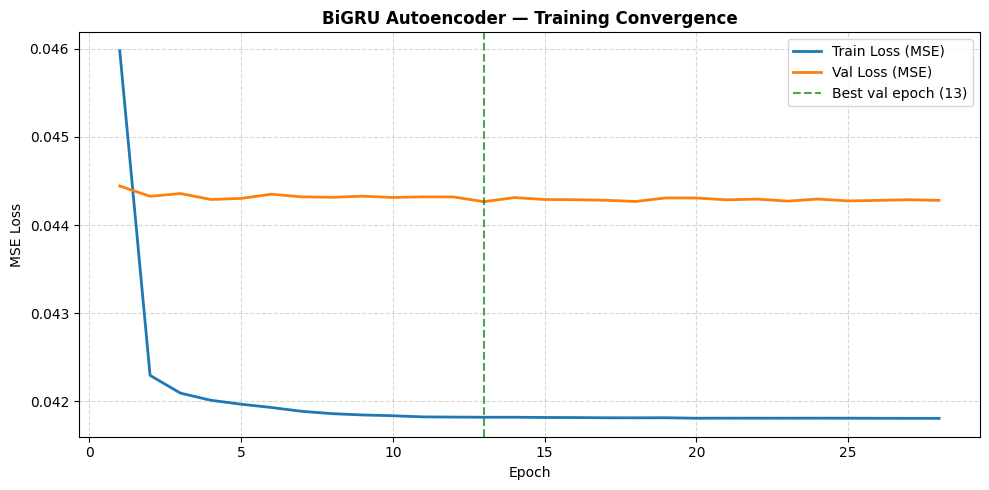

Convergence plot saved.


In [7]:
epochs_ran = range(1, len(train_losses) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_ran, train_losses, label='Train Loss (MSE)', color='#1f77b4', linewidth=2)
ax.plot(epochs_ran, val_losses,   label='Val Loss (MSE)',   color='#ff7f0e', linewidth=2)
ax.axvline(x=np.argmin(val_losses) + 1, color='green', linestyle='--',
           alpha=0.7, label=f'Best val epoch ({np.argmin(val_losses)+1})')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('BiGRU Autoencoder — Training Convergence', fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('convergence_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Convergence plot saved.')

## 2.5 — Load best weights and set anomaly threshold

The anomaly threshold is set at the **95th percentile** of reconstruction errors on the validation set.
This means 5% of known-normal validation flows will exceed the threshold — an acceptable false positive
rate that avoids the 50%+ FPR seen when using the median.

Reconstruction error per sequence = mean squared error across all timesteps and features.

In [12]:
# Load best checkpoint
model.load_state_dict(torch.load('gru_best_model.pt', map_location=DEVICE))
model.eval()
print('Best weights loaded.')

# ── Compute reconstruction errors on validation set ───────────────────────────
val_errors = []
with torch.no_grad():
    for (batch,) in val_loader:
        batch    = batch.to(DEVICE)
        recon, _ = model(batch)
        # Per-sequence MSE: mean over (window, features)
        errors   = torch.mean((batch - recon) ** 2, dim=(1, 2))
        val_errors.extend(errors.cpu().numpy())

val_errors = np.array(val_errors)

# ── Set threshold at 95th percentile ─────────────────────────────────────────
THRESHOLD_T = np.percentile(val_errors, 90)

print(f'\nValidation reconstruction errors:')
print(f'  Min    : {val_errors.min():.6f}')
print(f'  Mean   : {val_errors.mean():.6f}')
print(f'  Median : {np.median(val_errors):.6f}')
print(f'  95th % : {THRESHOLD_T:.6f}  <- THRESHOLD_T')
print(f'  Max    : {val_errors.max():.6f}')
print(f'\n5% of normal validation flows exceed this threshold (expected behaviour).')

Best weights loaded.

Validation reconstruction errors:
  Min    : 0.002171
  Mean   : 0.044266
  Median : 0.043385
  95th % : 0.064853  <- THRESHOLD_T
  Max    : 0.125928

5% of normal validation flows exceed this threshold (expected behaviour).


## 2.6 — Threshold visualisation

The distribution of validation reconstruction errors with the threshold marked.
A well-trained autoencoder shows a tight, low-error distribution for normal traffic.

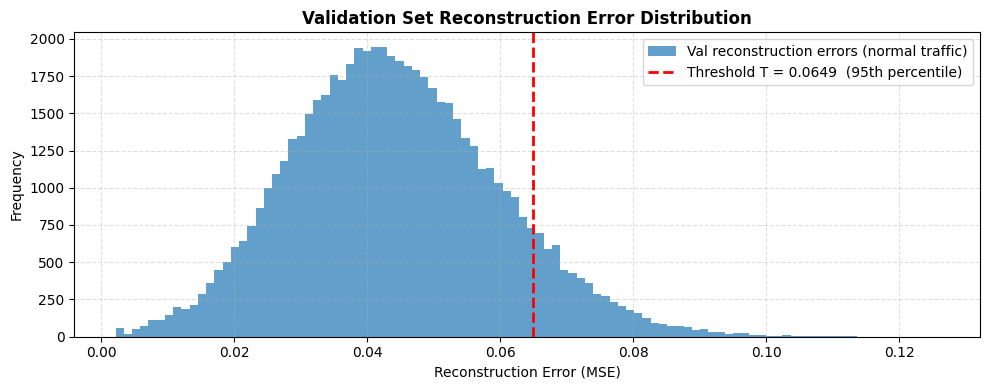

Threshold distribution plot saved.


In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(val_errors, bins=100, color='#1f77b4', alpha=0.7,
        label='Val reconstruction errors (normal traffic)')
ax.axvline(THRESHOLD_T, color='red', linewidth=2, linestyle='--',
           label=f'Threshold T = {THRESHOLD_T:.4f}  (95th percentile)')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Frequency')
ax.set_title('Validation Set Reconstruction Error Distribution', fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('threshold_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Threshold distribution plot saved.')

## 2.7 — Stage 2 handoff summary

In [14]:
print('=' * 60)
print('STAGE 2 COMPLETE')
print('=' * 60)
print(f'Architecture      : BiGRU encoder / UniGRU decoder')
print(f'Hidden size       : 64  (encoder output: 128 bidirectional)')
print(f'Bottleneck        : 128 -> 32')
print(f'Total parameters  : {sum(p.numel() for p in model.parameters()):,}')
print(f'Best val MSE      : {best_val_loss:.6f}')
print(f'Epochs trained    : {len(train_losses)}')
print(f'Threshold T       : {THRESHOLD_T:.6f}  (95th percentile on val)')
print()
print('Ready for Stage 3 — Base Detector Evaluation')
print('  model         : loaded with best weights')
print('  THRESHOLD_T   : set')
print('  NOTE: Do NOT freeze model yet — Stage 3 evaluates first.')
print('  Freeze happens at the START of Stage 4.')
print('=' * 60)

STAGE 2 COMPLETE
Architecture      : BiGRU encoder / UniGRU decoder
Hidden size       : 64  (encoder output: 128 bidirectional)
Bottleneck        : 128 -> 32
Total parameters  : 120,501
Best val MSE      : 0.044266
Epochs trained    : 28
Threshold T       : 0.064853  (95th percentile on val)

Ready for Stage 3 — Base Detector Evaluation
  model         : loaded with best weights
  THRESHOLD_T   : set
  NOTE: Do NOT freeze model yet — Stage 3 evaluates first.
  Freeze happens at the START of Stage 4.


In [15]:
# ── Save Stage 2 outputs to Google Drive ─────────────────────
torch.save(model.state_dict(), SAVE_DIR + 'gru_best_model.pt')

with open(SAVE_DIR + 'stage2_assets.pkl', 'wb') as f:
    pickle.dump({
        'THRESHOLD_T' : THRESHOLD_T,
        'train_losses': train_losses,
        'val_losses'  : val_losses,
        'best_val_loss': best_val_loss,
    }, f)

print('Stage 2 assets saved to Google Drive.')
print(f'  gru_best_model.pt')
print(f'  stage2_assets.pkl')
print(f'  THRESHOLD_T = {THRESHOLD_T:.6f}')

Stage 2 assets saved to Google Drive.
  gru_best_model.pt
  stage2_assets.pkl
  THRESHOLD_T = 0.064853
